# Data Preparation

In [1]:
import pandas as pd
import numpy as np
#Data import
df = pd.read_csv('../data/raw/alkanes_Stenutz.csv')

In [2]:
#add smiles
from src.utils.add_smiles import get_smiles
df['smiles'] = df.apply(lambda row: get_smiles(row['name']), axis=1)
df['smiles'] = df['smiles'].astype(str)
df

,name,number_ofC,molecular_weight,density,molar_volume,refractive_index,Molecular_refractive_power,dielectric_constant,melting_point,boiling_point,vapour_pressure,surface_tension,viscosity,logP,Tc,Pc,Vc,smiles
0,methane,1,16.04,0.424,37.8,1.0004,0.01,1.70,-183.00,-164,NaN,NaN,NaN,1.09,-82.0,45.6,99.0,C
1,ethane,2,30.07,0.546,55.1,1.2120,7.44,NaN,-182.00,-89,3.85,NaN,NaN,1.81,32.0,39.6,148.0,CC
2,propane,3,44.10,0.581,75.9,1.3400,15.90,1.60,-188.00,-45,NaN,NaN,NaN,2.36,97.0,42.0,203.0,CCC
3,butane,4,58.12,0.579,100.4,1.3560,21.95,1.77,-138.00,1,214.00,12.46,NaN,2.89,153.0,36.0,255.0,CCCC
4,isobutane,4,58.12,0.593,98.0,1.3520,21.20,NaN,-145.00,-12,304.00,NaN,NaN,2.76,135.0,36.0,263.0,CC(C)C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,"2,3,3-trimethylhexane",9,128.26,0.738,173.8,1.4140,43.44,NaN,-117.00,138,NaN,NaN,NaN,NaN,308.0,21.1,484.3,CCCC(C)(C)C(C)C
71,"2,3,4-trimethylhexane",9,128.26,0.739,173.5,1.4140,43.39,NaN,-116.79,139,NaN,NaN,NaN,NaN,311.0,22.0,483.5,CCC(C)C(C)C(C)C
72,"2,3,5-trimethylhexane",9,128.26,0.717,178.9,1.4050,43.85,NaN,-128.00,131,NaN,NaN,NaN,NaN,295.0,20.8,498.5,CC(C)CC(C)C(C)C
73,"2,4,4-trimethylhexane",9,128.26,0.724,177.2,1.4070,43.66,NaN,-113.00,131,NaN,NaN,NaN,NaN,295.0,20.6,493.8,CCC(C)(C)CC(C)C


In [3]:
#Calculate graph features: perron frobenius, information content, compression ratio, fiddler eigenvalue
from src.utils.graph_properties_calc import perron_frobenius,information_content,compression_ratio,fiedler_eigenvalue
# 1. Perron-Frobenius (Expects SMILES string -> Adjacency Matrix -> Eigenvalue)
df['perron_frobenius'] = df['smiles'].apply(perron_frobenius)

# 2. Information Content (Expects SMILES string -> Graph Symmetry -> Entropy)
df['information_content'] = df['smiles'].apply(information_content)

# 3. Compression Ratio (Expects SMILES string -> Compressed Bytes -> Ratio)
df['compression_ratio'] = df['smiles'].apply(compression_ratio)

# 4. Fiedler Eigenvalue (Expects SMILES string -> Laplacian Matrix -> Eigenvalue)
df['fiedler_eigenvalue'] = df['smiles'].apply(fiedler_eigenvalue)

df

,name,number_ofC,molecular_weight,density,molar_volume,refractive_index,Molecular_refractive_power,dielectric_constant,melting_point,boiling_point,...,viscosity,logP,Tc,Pc,Vc,smiles,perron_frobenius,information_content,compression_ratio,fiedler_eigenvalue
0,methane,1,16.04,0.424,37.8,1.0004,0.01,1.70,-183.00,-164,...,NaN,1.09,-82.0,45.6,99.0,C,0.000000,0.0000,0.0000,0.000000
1,ethane,2,30.07,0.546,55.1,1.2120,7.44,NaN,-182.00,-89,...,NaN,1.81,32.0,39.6,148.0,CC,1.000000,0.0000,0.5000,2.000000
2,propane,3,44.10,0.581,75.9,1.3400,15.90,1.60,-188.00,-45,...,NaN,2.36,97.0,42.0,203.0,CCC,1.414214,0.9183,0.6667,1.000000
3,butane,4,58.12,0.579,100.4,1.3560,21.95,1.77,-138.00,1,...,NaN,2.89,153.0,36.0,255.0,CCCC,1.618034,1.0000,0.5000,0.585786
4,isobutane,4,58.12,0.593,98.0,1.3520,21.20,NaN,-145.00,-12,...,NaN,2.76,135.0,36.0,263.0,CC(C)C,1.732051,0.8113,0.3333,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,"2,3,3-trimethylhexane",9,128.26,0.738,173.8,1.4140,43.44,NaN,-117.00,138,...,NaN,NaN,308.0,21.1,484.3,CCCC(C)(C)C(C)C,2.236068,2.7255,1.1667,0.223239
71,"2,3,4-trimethylhexane",9,128.26,0.739,173.5,1.4140,43.39,NaN,-116.79,139,...,NaN,NaN,311.0,22.0,483.5,CCC(C)C(C)C(C)C,2.164612,2.9477,1.5556,0.211786
72,"2,3,5-trimethylhexane",9,128.26,0.717,178.9,1.4050,43.85,NaN,-128.00,131,...,NaN,NaN,295.0,20.8,498.5,CC(C)CC(C)C(C)C,2.116883,2.7255,1.1667,0.183044
73,"2,4,4-trimethylhexane",9,128.26,0.724,177.2,1.4070,43.66,NaN,-113.00,131,...,NaN,NaN,295.0,20.6,493.8,CCC(C)(C)CC(C)C,2.193993,2.7255,1.1667,0.204260


Now we have our starting dataset. To see what will be more usable from the features, we need to measure the %coverage:

In [4]:
# Count alkanes
count = len(df['name'])
print(f"Number of alkanes in file: {count}")
if count == 75:
    print('75 Alkanes, Dataset is correctly formatted')

Number of alkanes in file: 75
75 Alkanes, Dataset is correctly formatted


In [5]:
from src.utils.alkanes_counter import per_alkane_missing_counts, feature_availability

print(f"Loaded data with {len(df)} rows and {len(df.columns)} columns.")

# 2. Run Per-Alkane Analysis
df_alkanes = per_alkane_missing_counts(df)
print("\n=== Per-alkane missing counts (Best 5) ===")
print(df_alkanes.head(5))

print("\n=== Per-alkane missing counts (Worst 5) ===")
print(df_alkanes.tail(5))

# 3. Run Feature Analysis
df_features = feature_availability(df)
print("\n=== Feature availability (Best to Worst) ===")
print(df_features[["missing", "available", "availability_rate"]])

# 4. Show worst features specifically
print("\n=== Most incomplete features (Worst 10) ===")
worst = df_features.sort_values(["availability_rate", "missing"], ascending=[True, False]).head(10)
print(worst[["missing", "total", "availability_rate"]])

Loaded data with 75 rows and 22 columns.

=== Per-alkane missing counts (Best 5) ===
         missing  total  available
name                              
pentane        0     21         21
hexane         0     21         21
heptane        0     21         21
octane         0     21         21
nonane         0     21         21

=== Per-alkane missing counts (Worst 5) ===
                       missing  total  available
name                                            
2,3,3-trimethylhexane        5     21         16
2,3,4-trimethylhexane        5     21         16
2,3,5-trimethylhexane        5     21         16
2,4,4-trimethylhexane        5     21         16
3,3,4-trimethylhexane        5     21         16

=== Feature availability (Best to Worst) ===
                            missing  available  availability_rate
number_ofC                        0         75         100.000000
molecular_weight                  0         75         100.000000
density                           0   

We are going to drop the columns with feature availability rate <90%

In [6]:
THRESHOLD = 0.90
availability_rates = df.count() / len(df)
df = df.loc[:, availability_rates > THRESHOLD]
df

,name,number_ofC,molecular_weight,density,molar_volume,refractive_index,Molecular_refractive_power,melting_point,boiling_point,Tc,Pc,Vc,smiles,perron_frobenius,information_content,compression_ratio,fiedler_eigenvalue
0,methane,1,16.04,0.424,37.8,1.0004,0.01,-183.00,-164,-82.0,45.6,99.0,C,0.000000,0.0000,0.0000,0.000000
1,ethane,2,30.07,0.546,55.1,1.2120,7.44,-182.00,-89,32.0,39.6,148.0,CC,1.000000,0.0000,0.5000,2.000000
2,propane,3,44.10,0.581,75.9,1.3400,15.90,-188.00,-45,97.0,42.0,203.0,CCC,1.414214,0.9183,0.6667,1.000000
3,butane,4,58.12,0.579,100.4,1.3560,21.95,-138.00,1,153.0,36.0,255.0,CCCC,1.618034,1.0000,0.5000,0.585786
4,isobutane,4,58.12,0.593,98.0,1.3520,21.20,-145.00,-12,135.0,36.0,263.0,CC(C)C,1.732051,0.8113,0.3333,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,"2,3,3-trimethylhexane",9,128.26,0.738,173.8,1.4140,43.44,-117.00,138,308.0,21.1,484.3,CCCC(C)(C)C(C)C,2.236068,2.7255,1.1667,0.223239
71,"2,3,4-trimethylhexane",9,128.26,0.739,173.5,1.4140,43.39,-116.79,139,311.0,22.0,483.5,CCC(C)C(C)C(C)C,2.164612,2.9477,1.5556,0.211786
72,"2,3,5-trimethylhexane",9,128.26,0.717,178.9,1.4050,43.85,-128.00,131,295.0,20.8,498.5,CC(C)CC(C)C(C)C,2.116883,2.7255,1.1667,0.183044
73,"2,4,4-trimethylhexane",9,128.26,0.724,177.2,1.4070,43.66,-113.00,131,295.0,20.6,493.8,CCC(C)(C)CC(C)C,2.193993,2.7255,1.1667,0.204260


In [7]:
df_numeric = df.drop(columns=['name', 'smiles'])
df_numeric

,number_ofC,molecular_weight,density,molar_volume,refractive_index,Molecular_refractive_power,melting_point,boiling_point,Tc,Pc,Vc,perron_frobenius,information_content,compression_ratio,fiedler_eigenvalue
0,1,16.04,0.424,37.8,1.0004,0.01,-183.00,-164,-82.0,45.6,99.0,0.000000,0.0000,0.0000,0.000000
1,2,30.07,0.546,55.1,1.2120,7.44,-182.00,-89,32.0,39.6,148.0,1.000000,0.0000,0.5000,2.000000
2,3,44.10,0.581,75.9,1.3400,15.90,-188.00,-45,97.0,42.0,203.0,1.414214,0.9183,0.6667,1.000000
3,4,58.12,0.579,100.4,1.3560,21.95,-138.00,1,153.0,36.0,255.0,1.618034,1.0000,0.5000,0.585786
4,4,58.12,0.593,98.0,1.3520,21.20,-145.00,-12,135.0,36.0,263.0,1.732051,0.8113,0.3333,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,9,128.26,0.738,173.8,1.4140,43.44,-117.00,138,308.0,21.1,484.3,2.236068,2.7255,1.1667,0.223239
71,9,128.26,0.739,173.5,1.4140,43.39,-116.79,139,311.0,22.0,483.5,2.164612,2.9477,1.5556,0.211786
72,9,128.26,0.717,178.9,1.4050,43.85,-128.00,131,295.0,20.8,498.5,2.116883,2.7255,1.1667,0.183044
73,9,128.26,0.724,177.2,1.4070,43.66,-113.00,131,295.0,20.6,493.8,2.193993,2.7255,1.1667,0.204260


## Coorelation matrix:

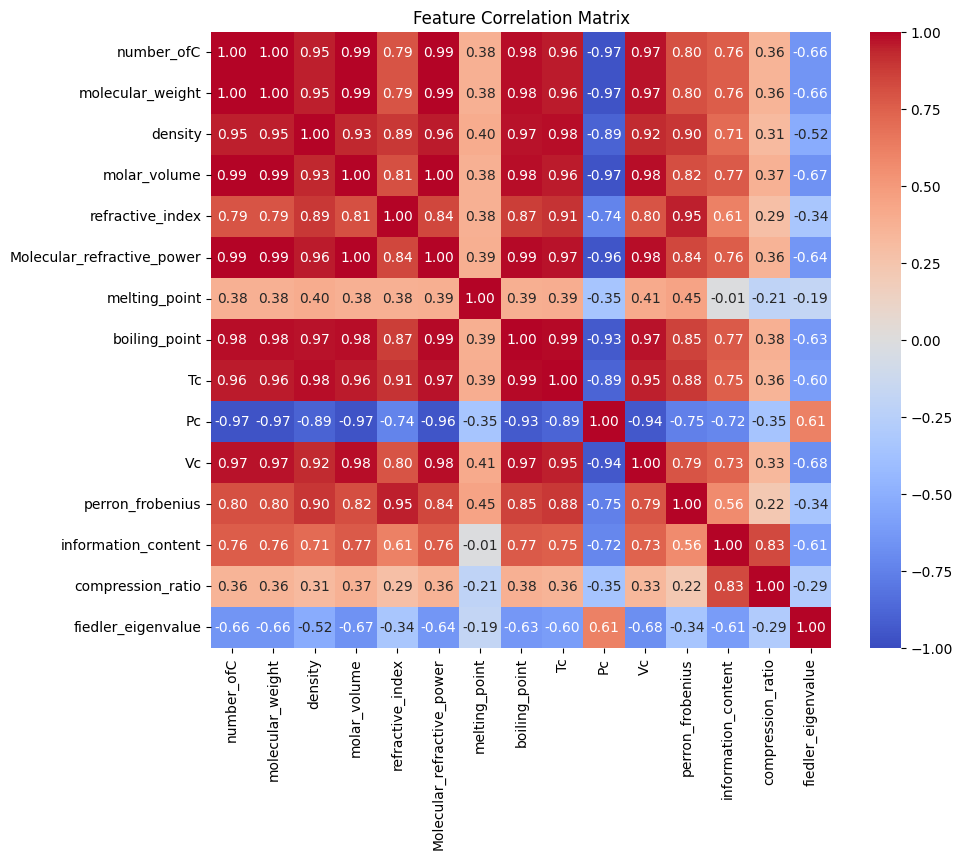

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate Correlation Matrix
corr_matrix = df_numeric.corr()

# 2. Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,     # Show the numbers
    fmt=".2f",      # 2 decimal places
    cmap='coolwarm',# Red = High Correlation, Blue = Low
    center=0,       # Center the colors at 0
    vmin=-1, vmax=1 # Fix scale from -1 to 1
)
plt.title("Feature Correlation Matrix")
plt.show()

In [9]:
# Based on this heatmap we drop the ones with high correlation (>0.95)
cols_to_drop = [
    'number_ofC',
    'molar_volume',
    'molecular_refractive_power',
    'Pc',
    'Tc',
    'boiling_point',
    'density',
    'Vc'
]

# Drop them if they exist in your dataframe
existing_drops = [c for c in cols_to_drop if c in df_numeric.columns]
df_kpca_ready = df_numeric.drop(columns=existing_drops)

print(f"Features remaining for kpca: {df_kpca_ready.columns.tolist()}")

Features remaining for kpca: ['molecular_weight', 'refractive_index', 'Molecular_refractive_power', 'melting_point', 'perron_frobenius', 'information_content', 'compression_ratio', 'fiedler_eigenvalue']


## Validation Setup & Scaling

In [10]:
from sklearn.model_selection import train_test_split
X = df_kpca_ready

# Split 80/20
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on TRAIN, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Hyperparameter tuning for Kernel PCA

In [12]:
np.random.seed(42)
RANDOM_SEED = 42
N_GAMMA_POINTS = 100

In [13]:
GAMMA_RANGE = np.logspace(-4, 1, N_GAMMA_POINTS)

In [14]:
from sklearn.decomposition import KernelPCA
spectral_gaps = []

for gamma_val in GAMMA_RANGE:
    # Kernel Principal Component Analysis with RBF kernel
    kpca = KernelPCA(kernel='rbf', gamma=gamma_val, fit_inverse_transform=False, random_state=RANDOM_SEED)
    kpca.fit(X_train_scaled)

    # Get eigenvalues (lambdas)
    lambdas = kpca.eigenvalues_

    # Sort eigenvalues in descending order
    lambdas = np.sort(lambdas)[::-1]

    # Calculate differences between consecutive eigenvalues (the gaps)
    # The spectral gap is the largest jump, separating signal (manifold) from noise.
    diffs = np.diff(lambdas)

    # Find the maximum difference (the spectral gap) in the first few components
    # We restrict to the first 10 gaps to focus on the major structural variations [cite: 931]
    gap = np.max(np.abs(diffs[:10]))
    spectral_gaps.append(gap)

In [15]:
# Find the Optimal Gamma
best_index = np.argmax(spectral_gaps)
best_gamma = GAMMA_RANGE[best_index]
max_gap = spectral_gaps[best_index]

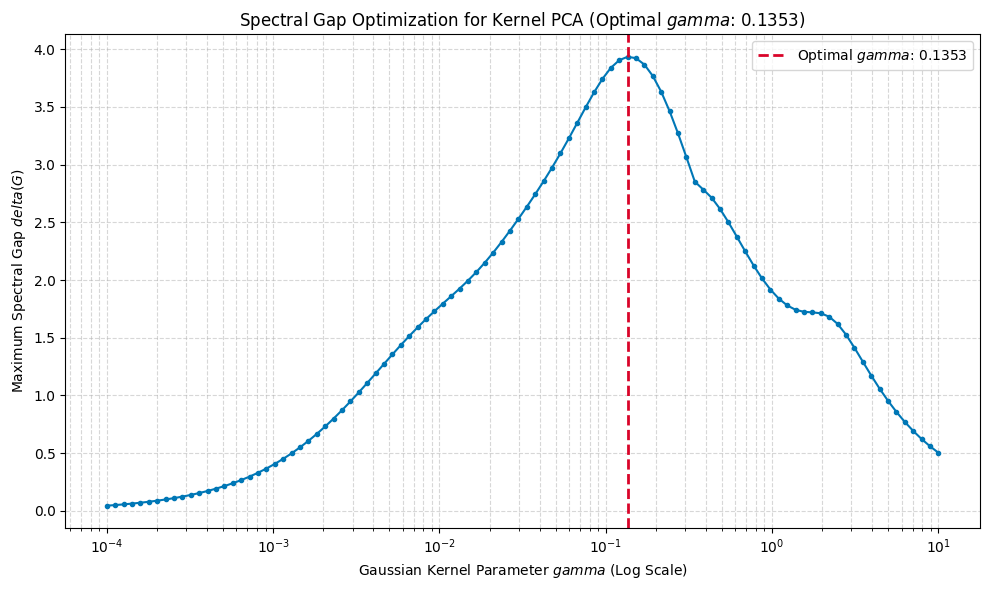


--- Optimization Result ---
Optimal Gamma (gamma) found: 0.135305
Maximum Spectral Gap (delta(G)): 3.934781
We will use this value = 0.135305 in our final KPCA and Regression models.


In [16]:
# Generate the Plot of SPECTRAL GAPS vs. Gamma

plt.figure(figsize=(10, 6))
# Use log scale for the X-axis (Gamma) as it was iterated logarithmically
plt.semilogx(GAMMA_RANGE, spectral_gaps, marker='o', linestyle='-', color='#0077b6', markersize=3)
plt.xlabel('Gaussian Kernel Parameter $gamma$ (Log Scale)')
plt.ylabel('Maximum Spectral Gap $delta(G)$')
plt.title(f'Spectral Gap Optimization for Kernel PCA (Optimal $gamma$: {best_gamma:.4f})')
plt.grid(True, which="both", ls="--", alpha=0.5)

# Highlight the optimal gamma with a vertical line
plt.axvline(best_gamma, color='#d90429', linestyle='--', linewidth=2, label=f'Optimal $gamma$: {best_gamma:.4f}')
plt.legend()
plt.tight_layout()

plt.show()

print(f"\n--- Optimization Result ---")
print(f"Optimal Gamma (gamma) found: {best_gamma:.6f}")
print(f"Maximum Spectral Gap (delta(G)): {max_gap:.6f}")
print(f"We will use this value = {best_gamma:.6f} in our final KPCA and Regression models.")

In [17]:
from sklearn.metrics.pairwise import rbf_kernel

K = rbf_kernel(X_train_scaled, gamma=best_gamma)

Estimated Intrinsic Dimension: 15


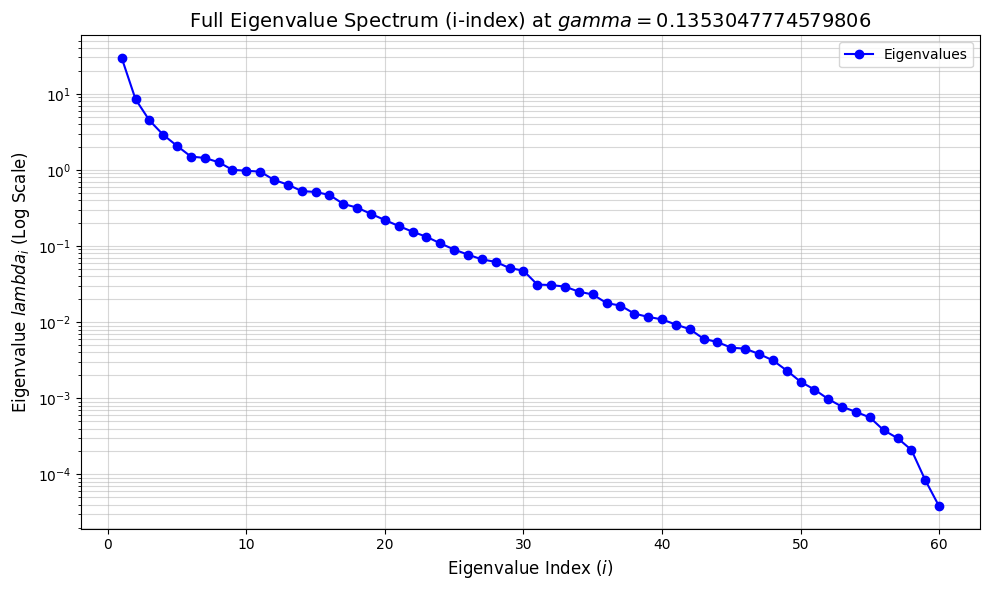

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def estimate_intrinsic_dimension(eigenvals, threshold=0.95):
    """
    Dynamically estimates intrinsic dimension using different heuristics.
    """
    # Ensure eigenvalues are positive and sorted descending
    vals = np.maximum(eigenvals, 1e-9) # Avoid division by zero
    total_variance = np.sum(vals)
    cumulative_variance = np.cumsum(vals)
    # Find the first index where cumulative variance exceeds a threshold
    return np.searchsorted(cumulative_variance / total_variance, threshold) + 1

# Compute Eigenvalues
evs, _ = np.linalg.eigh(K)
# Sort eigenvalues in Descending order
evs = evs[::-1]

# --- DYNAMIC CALCULATION ---

# Calculate the gap index dynamically
gap_index = estimate_intrinsic_dimension(evs, threshold=0.95)

print(f"Estimated Intrinsic Dimension: {gap_index}")

# --- PLOTTING ---

plt.figure(figsize=(10, 6))

# Plot the spectrum
plt.plot(range(1, len(evs) + 1), evs, marker='o', linestyle='-', color='b', label='Eigenvalues')
plt.yscale('log')

# Formatting
plt.title(f'Full Eigenvalue Spectrum (i-index) at $gamma={best_gamma}$', fontsize=14)
plt.xlabel('Eigenvalue Index ($i$)', fontsize=12)
plt.ylabel('Eigenvalue $lambda_i$ (Log Scale)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)

# Plot the dynamic vertical line
#plt.axvline(x=gap_index, color='r', linestyle='--', linewidth=2, label=f'Intrinsic Dim = {gap_index}')

plt.legend()
plt.tight_layout()
plt.show()

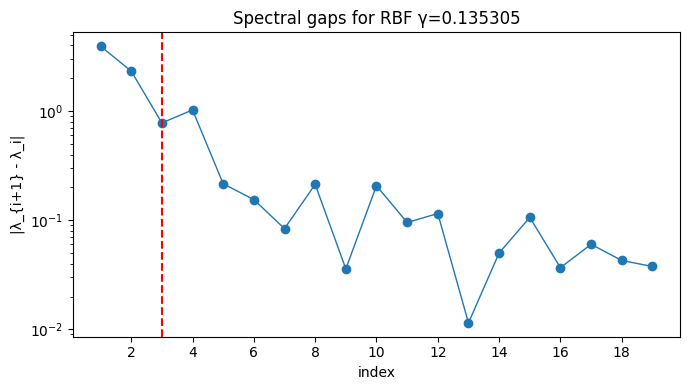

{'eigvals': array([9.7154892 , 5.78070788, 3.45587261, 2.67580657, 1.65135508,
       1.43540586, 1.28080104, 1.19691495, 0.98365756, 0.94777397,
       0.74039706, 0.64499888, 0.52974368, 0.51826533, 0.46810824,
       0.36189476, 0.3251094 , 0.26491735, 0.22208339, 0.18436441]), 'diffs': array([3.93478132, 2.32483526, 0.78006605, 1.02445149, 0.21594922,
       0.15460482, 0.08388609, 0.21325739, 0.03588359, 0.20737691,
       0.09539818, 0.1152552 , 0.01147835, 0.05015708, 0.10621348,
       0.03678537, 0.06019205, 0.04283396, 0.03771898]), 'max_gap': 3.9347813246899612, 'gap_index_i': 1}


In [19]:
from matplotlib.ticker import MaxNLocator
from sklearn.preprocessing import KernelCenterer


#Absolute difference of successive eigenvalues
def spectral_gaps_plot(X_scaled, gamma, top_k=None, logy=False, title=None):
    """
    Υπολογίζει και κάνει plot τα |λ_{i+1} - λ_i| για τον centered Gram matrix του RBF kernel.
    - X_scaled: (N, D) scaled features
    - gamma: RBF parameter
    - top_k: αν θες να κρατήσεις μόνο τις top_k ιδιοτιμές
    - logy: αν True, κάνει log-scale στον άξονα y για ευκρίνεια
    """
    # 1) Gram + centering
    K = rbf_kernel(X_scaled, X_scaled, gamma=gamma)
    Kc = KernelCenterer().fit_transform(K)

    # 2) Eigenvalues (συμμετρικός πίνακας) σε φθίνουσα σειρά
    eigvals = np.linalg.eigvalsh(Kc)[::-1]
    if top_k is not None:
        eigvals = eigvals[:top_k]

    # 3) Διαφορά διαδοχικών ιδιοτιμών (απόλυτη τιμή)
    diffs = np.abs(np.diff(eigvals))
    idx = np.argmax(diffs)  # θέση μέγιστου gap
    max_gap = diffs[idx]
    intrinsic_d = idx + 1.0    # εκτίμηση intrinsic dimension

    # 4) Plot
    fig, ax = plt.subplots(figsize=(7,4))
    ax.plot(np.arange(1, len(diffs)+1), diffs, marker='o', linewidth=1)
    ax.axvline(x= 3, ls='--', color='red')
    ax.set_xlabel("index")
    ax.set_ylabel("|λ_{i+1} - λ_i|")

    if logy:
        ax.set_yscale('log')

    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    if title is None:
        title = f"Spectral gaps for RBF γ={gamma:g}"
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return {
        "eigvals": eigvals,
        "diffs": diffs,
        "max_gap": float(max_gap),
        "gap_index_i": int(intrinsic_d)  # d ≈ intrinsic dimension
    }

res = spectral_gaps_plot(X_train_scaled, gamma=best_gamma, top_k=20, logy=True)
print(res)

In [20]:

total_variance = np.sum(evs)
cumulative_variance = np.cumsum(evs)
cumulative_ratio = cumulative_variance / total_variance

print(f"Total Variance (Trace): {total_variance:.4f}")
for k, ratio in enumerate(cumulative_ratio[:12]):
    print(f"Component {k+1}: {ratio:.4f} ({ratio*100:.2f}%)")

Total Variance (Trace): 60.0000
Component 1: 0.4949 (49.49%)
Component 2: 0.6363 (63.63%)
Component 3: 0.7110 (71.10%)
Component 4: 0.7591 (75.91%)
Component 5: 0.7935 (79.35%)
Component 6: 0.8184 (81.84%)
Component 7: 0.8423 (84.23%)
Component 8: 0.8633 (86.33%)
Component 9: 0.8800 (88.00%)
Component 10: 0.8962 (89.62%)
Component 11: 0.9120 (91.20%)
Component 12: 0.9243 (92.43%)


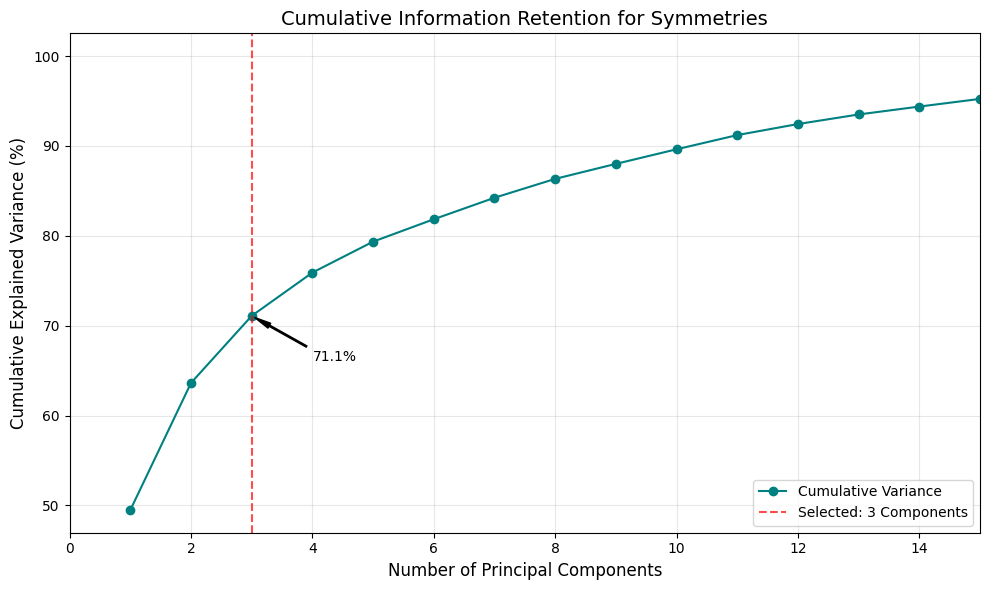

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

x_axis = np.arange(1, len(cumulative_ratio) + 1)

plt.plot(x_axis, cumulative_ratio * 100, marker='o', linestyle='-', color='teal', label='Cumulative Variance')

plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Selected: 3 Components')
plt.annotate(f'{cumulative_ratio[2]*100:.1f}%',
             xy=(3, cumulative_ratio[2]*100),
             xytext=(4, cumulative_ratio[2]*100 - 5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=4))

plt.title('Cumulative Information Retention for Symmetries', fontsize=14)
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance (%)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.xlim(0, 15)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

## KPCA

In [22]:
# Initialize kPCA
# n_components: How many dimensions you want to keep
# kernel='rbf': Standard for graphs/molecules
# gamma: None (defaults to 1/n_features) or tuned.
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=best_gamma, fit_inverse_transform=True, random_state=42)

# Fit on TRAIN
X_train_kpca = kpca.fit_transform(X_train_scaled)

# Transform TEST (projects test data onto the training manifold)
X_test_kpca = kpca.transform(X_test_scaled)

print(f"Original Shape: {X_train_scaled.shape}")
print(f"kPCA Shape:     {X_train_kpca.shape}")

Original Shape: (60, 8)
kPCA Shape:     (60, 2)


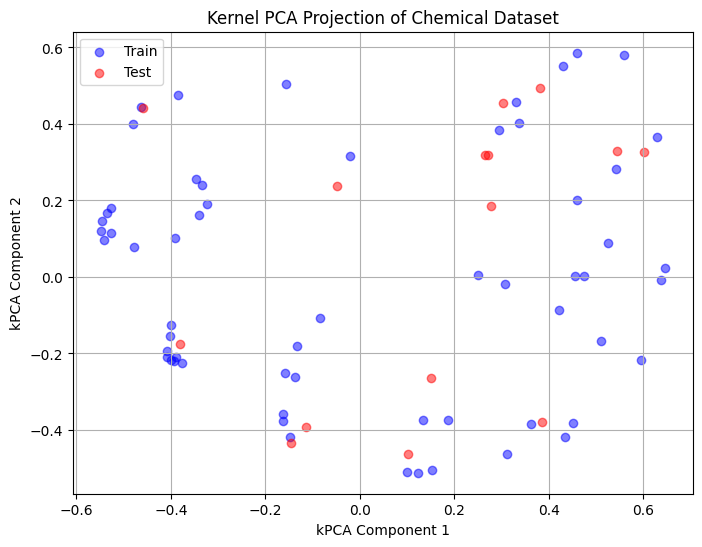

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X_train_kpca[:, 0], X_train_kpca[:, 1], c='blue', alpha=0.5, label='Train')
plt.scatter(X_test_kpca[:, 0], X_test_kpca[:, 1], c='red', alpha=0.5, label='Test')
plt.title("Kernel PCA Projection of Chemical Dataset")
plt.xlabel("kPCA Component 1")
plt.ylabel("kPCA Component 2")
plt.legend()
plt.grid(True)
plt.show()

### Reconstruction Error (How much info was lost?)
This measures how accurately we can recreate the original data from just your 2 kPCA components.

Low Error: Your 2 components captured the molecular structure well.

High Error: You need more components (increase n_components to 3 or 4).

In [24]:
import numpy as np
from sklearn.metrics import mean_squared_error

# 1. Project back to the original space (Pre-image approximation)
X_train_reconstructed = kpca.inverse_transform(X_train_kpca)

# 2. Calculate Mean Squared Error (MSE)
mse = mean_squared_error(X_train_scaled, X_train_reconstructed)

# 3. Explained Variance (Proxy based on eigenvalues)
# Note: This is variance in the *feature space*, not the original space
total_variance = np.sum(kpca.eigenvalues_)
explained_variance = np.sum(kpca.eigenvalues_[:2]) # First 2 components
variance_ratio = explained_variance / total_variance

print(f"Reconstruction MSE:      {mse:.4f} (Lower is better)")
print(f"Explained Variance:      {variance_ratio*100:.2f}% (In feature space)")

Reconstruction MSE:      0.5584 (Lower is better)
Explained Variance:      100.00% (In feature space)


### Interpretability: What do PC1 and PC2 mean?
In Kernel PCA, the axes are non-linear combinations, so they don't have simple loading vectors like standard PCA. To interpret them, we calculate the Spearman Correlation (rank correlation) between your new kPCA axes and the original physical properties.

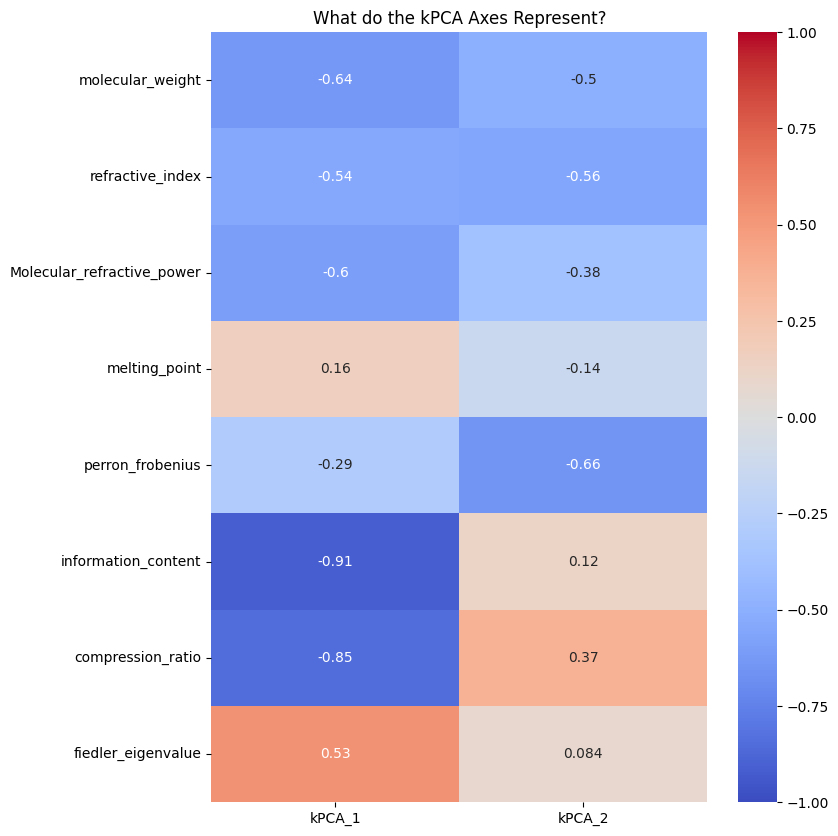

In [25]:
import seaborn as sns
import pandas as pd

# 1. Create a DataFrame for the kPCA components
df_kpca_components = pd.DataFrame(
    X_train_kpca,
    columns=['kPCA_1', 'kPCA_2'],
    index=X_train.index
)

# 2. Concatenate with original (scaled) features and the target (Melting Point)
# Ensure we map indices correctly
df_analysis = pd.concat([
    df_kpca_components,
    X_train.loc[df_kpca_components.index] # The original physical values
], axis=1)

# 3. Calculate Correlation
correlation_matrix = df_analysis.corr(method='spearman')

# 4. Plot Heatmap (Focusing on kPCA columns vsPhysical Features)
plt.figure(figsize=(8, 10))
sns.heatmap(
    correlation_matrix[['kPCA_1', 'kPCA_2']].drop(['kPCA_1', 'kPCA_2']), # Drop self-correlation
    annot=True,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1
)
plt.title("What do the kPCA Axes Represent?")
plt.show()

##  Feature Importance

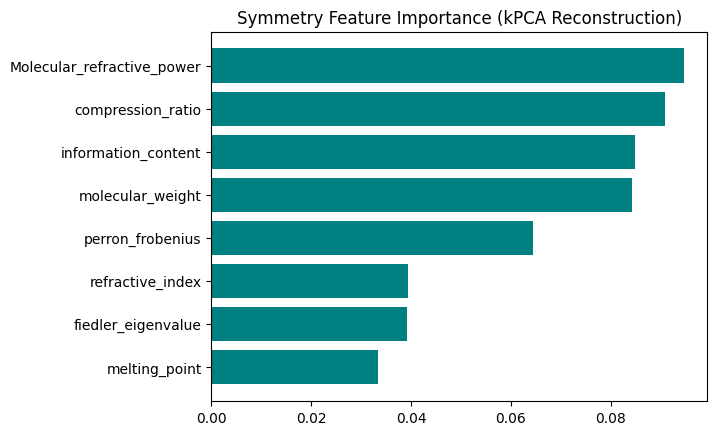

In [26]:
# 1. Setup
current_features = df_kpca_ready.columns
baseline_mse = mean_squared_error(X_train_scaled, kpca.inverse_transform(X_train_kpca))
importances = {}

# 2. Permutation Loop
for i, col_name in enumerate(current_features):
    # Create a deep copy to ensure we don't corrupt the original X_train_scaled
    X_corrupted = np.array(X_train_scaled, copy=True)

    # Shuffle only the i-th column
    np.random.shuffle(X_corrupted[:, i])

    # Transform using your established kPCA (ensure n_components is consistent)
    X_corrupted_proj = kpca.transform(X_corrupted)
    X_train_reconstructed = kpca.inverse_transform(X_corrupted_proj)

    # Calculate Error - compare corrupted recon to the original (uncorrupted) data
    new_mse = mean_squared_error(X_train_scaled, X_train_reconstructed)
    importances[col_name] = new_mse - baseline_mse

# 3. Final Plotting (Descending order is usually better for reading)
df_imp = pd.DataFrame(list(importances.items()), columns=['Feature', 'Importance']).sort_values('Importance', ascending=True)
plt.barh(df_imp['Feature'], df_imp['Importance'], color='teal')
plt.title("Symmetry Feature Importance (kPCA Reconstruction)")
plt.show()

## Anomaly Detection
Let's try detecting "Outliers" in this kPCA space (molecules that don't fit any cluster) using an Isolation Forest is a powerful unsupervised algorithm for detecting anomalies. It works particularly well here because it identifies data points that are "few and different" (isolated) in your kPCA space.

In [27]:
from sklearn.ensemble import IsolationForest

# 1. Initialize Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)

# 2. Fit and Predict (-1 = Outlier, 1 = Normal)
outlier_labels = iso_forest.fit_predict(X_train_kpca)

# 3. Add results to a dataframe for analysis
df_outliers = pd.DataFrame(X_train_kpca, columns=['kPCA_1', 'kPCA_2'], index=X_train.index)
df_outliers['Is_Outlier'] = outlier_labels
df_outliers['SMILES'] = df['smiles']
# Count how many we found
n_outliers = (outlier_labels == -1).sum()
print(f"Detected {n_outliers} outliers out of {len(X_train)} molecules.")

Detected 3 outliers out of 60 molecules.


Visualize the Anomalies
This plot highlights the "weird" molecules in red. They should be far away from the dense clusters.

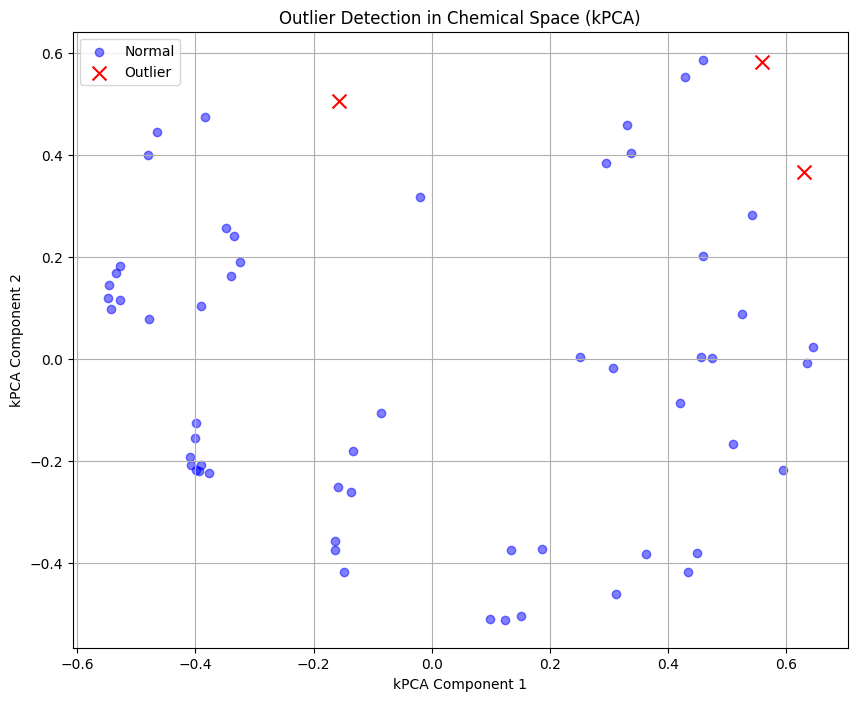

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Plot Normal points (Blue)
plt.scatter(
    df_outliers[df_outliers['Is_Outlier'] == 1]['kPCA_1'],
    df_outliers[df_outliers['Is_Outlier'] == 1]['kPCA_2'],
    c='blue', alpha=0.5, label='Normal'
)

# Plot Outliers (Red)
plt.scatter(
    df_outliers[df_outliers['Is_Outlier'] == -1]['kPCA_1'],
    df_outliers[df_outliers['Is_Outlier'] == -1]['kPCA_2'],
    c='red', marker='x', s=100, label='Outlier'
)

plt.title("Outlier Detection in Chemical Space (kPCA)")
plt.xlabel("kPCA Component 1")
plt.ylabel("kPCA Component 2")
plt.legend()
plt.grid(True)
plt.show()

#### Inspect the "Weirdest" Molecules
Now, let's look at the actual SMILES strings of these outliers. This is the most critical step

In [29]:
print("--- Top Detected Outliers ---")
weird_molecules = df_outliers[df_outliers['Is_Outlier'] == -1]
df_clean = X_train_kpca[df_outliers['Is_Outlier'] != -1]

for idx, row in weird_molecules.head(5).iterrows():
    print(f"Index: {idx} | kPCA Coords: ({row['kPCA_1']:.2f}, {row['kPCA_2']:.2f})")
    print(f"SMILES: {row['SMILES']}")
    print("-" * 40)

--- Top Detected Outliers ---
Index: 5 | kPCA Coords: (0.56, 0.58)
SMILES: CCCCC
----------------------------------------
Index: 8 | kPCA Coords: (0.63, 0.37)
SMILES: CCCCCC
----------------------------------------
Index: 15 | kPCA Coords: (-0.16, 0.50)
SMILES: CCCC(C)CC
----------------------------------------


### But why did we choose KPCA over simple PCA?

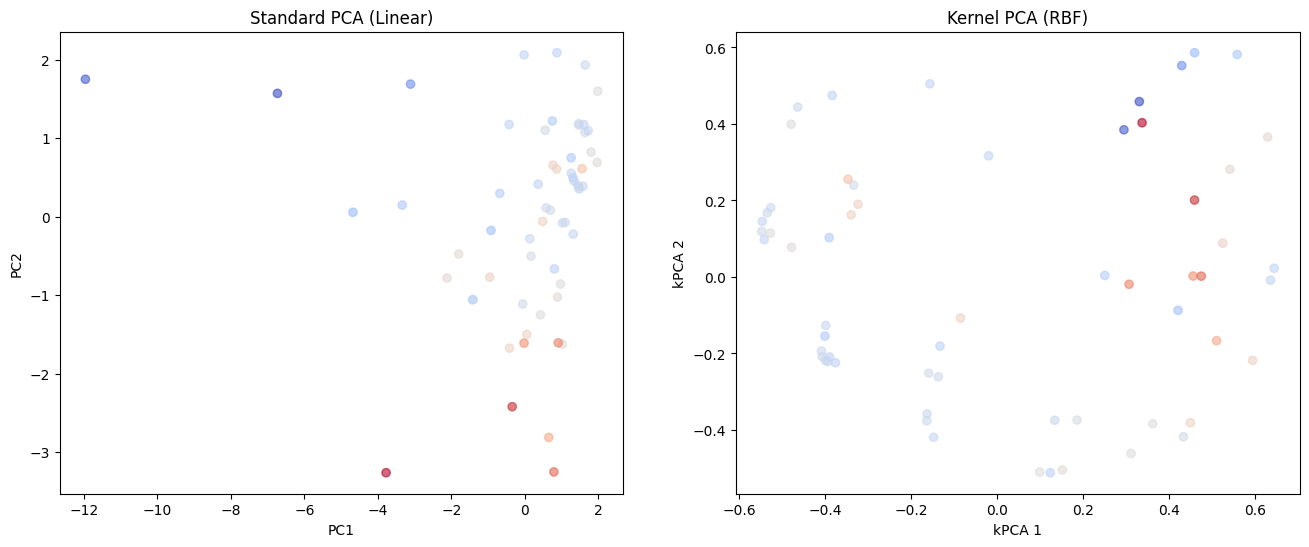

In [30]:
from sklearn.decomposition import PCA

# 1. Run Standard PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_train_scaled)

# 2. Plot Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot PCA (Linear)
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['melting_point'].loc[X_train.index], cmap='coolwarm', alpha=0.6)
axes[0].set_title("Standard PCA (Linear)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# Plot kPCA (Non-Linear) - Assuming X_train_kpca exists from your previous step
axes[1].scatter(X_train_kpca[:, 0], X_train_kpca[:, 1], c=df['melting_point'].loc[X_train.index], cmap='coolwarm', alpha=0.6)
axes[1].set_title("Kernel PCA (RBF)")
axes[1].set_xlabel("kPCA 1")
axes[1].set_ylabel("kPCA 2")

plt.show()

We can see that linear PCA collapsed the data into a dense overlap (left), whereas kPCA successfully unfolded the manifold to reveal distinct chemical families (right).

#  Clustering

First, we use the Elbow Method to decide how many natural groups exist in your data. We look for the "elbow" where adding more clusters stops improving the fit significantly.

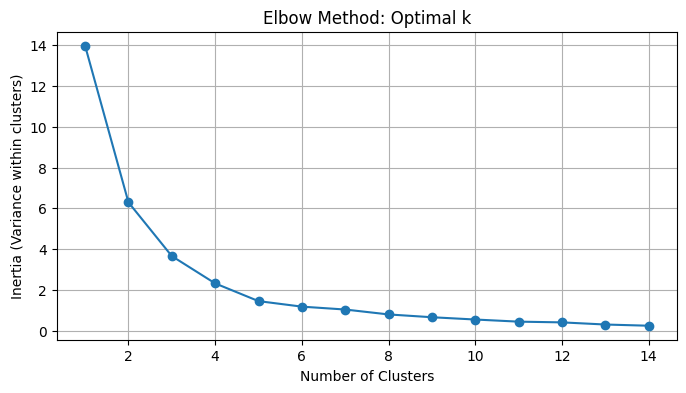

In [31]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_clean)
    inertia.append(kmeans.inertia_)

# Plot the Elbow
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method: Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (Variance within clusters)')
plt.grid(True)
plt.show()

##  Run K-Means and Visualize

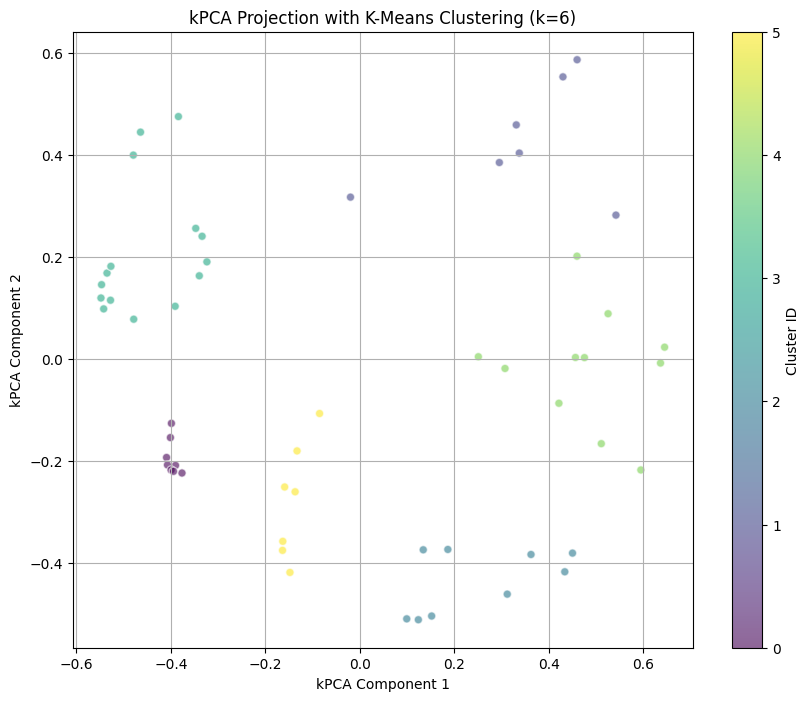

In [32]:
# 1. Fit K-Means
optimal_k = 6  #based on Elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_clean)

# 2. Visualize the Clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    df_clean[:, 0],
    df_clean[:, 1],
    c=cluster_labels,
    cmap='viridis',
    alpha=0.6,
    edgecolors='w'
)
plt.title(f"kPCA Projection with K-Means Clustering (k={optimal_k})")
plt.xlabel("kPCA Component 1")
plt.ylabel("kPCA Component 2")
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True)
plt.show()

###  Cluster Profiling
This is the most important part of your thesis. You need to connect these abstract Cluster IDs back to physical properties. We do this by calculating the mean values of your original features for each cluster.

In [33]:
# 1. Add Cluster Labels to your original Training Data
df_profile = X_train[df_outliers['Is_Outlier'] != -1].copy()
df_profile['Cluster'] = cluster_labels

# 2. Calculate the mean of physical properties for each cluster
cluster_summary = df_profile.groupby('Cluster').mean()

# 3. Add 'Count' to see how many molecules are in each cluster
cluster_summary['Count'] = df_profile['Cluster'].value_counts()

# Display the profile
print(cluster_summary)

         molecular_weight  refractive_index  Molecular_refractive_power  \
Cluster                                                                   
0              128.260000          1.408625                   43.476250   
1               66.138571          1.338143                   22.970000   
2              122.024444          1.405556                   41.308889   
3              123.583333          1.404800                   42.084667   
4              110.403636          1.395000                   37.843636   
5              120.242857          1.406571                   40.860000   

         melting_point  perron_frobenius  information_content  \
Cluster                                                         
0          -117.373750          2.164371             2.704525   
1          -128.714286          1.698025             1.268029   
2          -105.765556          2.161068             2.019678   
3          -107.256000          2.078441             2.928093   
4        

#### Quantitative Metrics: "How good are the clusters?"
We visualized clusters with K-Means, but "it looks good" isn't a number. We will ues the Silhouette Score to quantify how well-separated our chemical families are.

 *  \> 0.5: Strong structure. The chemical families are very distinct.

*  0.2–0.5: Moderate structure. There are groups, but they overlap (common in chemistry).

*  < 0.2: Weak structure.

In [34]:
from sklearn.metrics import silhouette_score

# Calculate the score for kPCA clusters
# ('cluster_labels' comes from our K-Means step)
score_kpca = silhouette_score(df_clean, cluster_labels)

print(f"Clustering Quality (Silhouette Score): {score_kpca:.3f}")

Clustering Quality (Silhouette Score): 0.547


### "Archetypes" —the molecules that sit at the very center of each cluster.

In [35]:
# Find the molecule closest to the center of each cluster
from sklearn.metrics import pairwise_distances_argmin_min

# Get the indices of the points closest to the K-Means centers
closest_indices, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X_train_kpca)

print("--- Representative Molecules (Cluster Centers) ---")
for i, idx in enumerate(closest_indices):
    smiles = df['smiles'].iloc[idx]
    print(f"Cluster {i} Center: {smiles}")

--- Representative Molecules (Cluster Centers) ---
Cluster 0 Center: CC(C)C(C)C
Cluster 1 Center: CCC(C)(C)C
Cluster 2 Center: CC(C)C
Cluster 3 Center: CCCC(C)C
Cluster 4 Center: CCC(C)C(C)(C)C
Cluster 5 Center: CCCC(CC)CC


# 3D KPCA try

In [36]:
from sklearn.decomposition import KernelPCA

# Re-fit with components calculated before
kpca_3d = KernelPCA(n_components=10, kernel='rbf', gamma=best_gamma, fit_inverse_transform=True, random_state=42)
X_train_kpca_3d = kpca_3d.fit_transform(X_train_scaled)
X_test_kpca_3d = kpca_3d.transform(X_test_scaled)

### Generate Interactive 3D Plot

In [37]:
evs = kpca_3d.eigenvalues_

best_3 = np.argsort(evs)[-3:][::-1]
col_names = [f'kPCA_{i+1}' for i in best_3]

print(f"Top 3 axes by variance: {col_names}")

Top 3 axes by variance: ['kPCA_1', 'kPCA_2', 'kPCA_3']


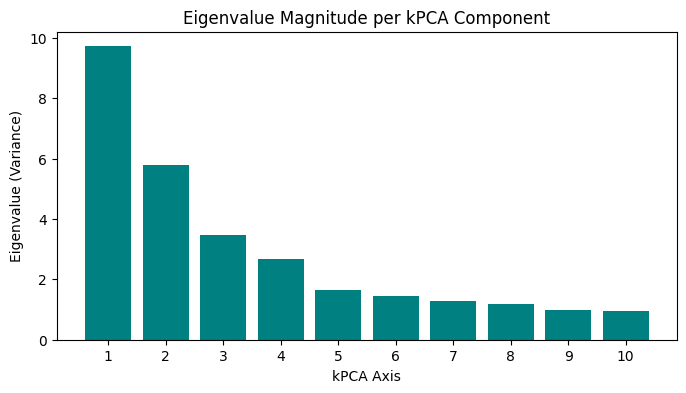

In [38]:
# Calculate the ratio of each eigenvalue to the total sum
importance_ratio = evs / np.sum(evs)

# Plot the justification
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(evs)+1), evs, color='teal')
plt.title("Eigenvalue Magnitude per kPCA Component")
plt.xlabel("kPCA Axis")
plt.ylabel("Eigenvalue (Variance)")
plt.xticks(range(1, 11))
plt.show()

In [39]:
import plotly.express as px
import pandas as pd

# 1. Use the FULL 3D array (60 rows) to create a DataFrame for plotting

# target_indices = [0, 1, 2] #for dynamic picking of axes
# col_names = [f'kPCA_{i+1}' for i in target_indices]

df_3d = pd.DataFrame(
    X_train_kpca_3d[:,best_3],
    columns=col_names,
    index=X_train.index
)

# 2. Add Metadata (All of these have 60 rows, so they match perfectly)
df_3d['SMILES'] = df.loc[X_train.index, 'smiles']
df_3d['Boiling Point'] = df.loc[X_train.index, 'boiling_point']
df_3d['Outlier'] = df_outliers['Is_Outlier'].astype(str) # Convert to string for discrete shapes

# 3. Handle the 57 Cluster Labels safely
# First, set everything to a default string
df_3d['Cluster'] = "Anomaly"

# Next, apply your 57 cluster labels ONLY to the rows that are NOT outliers
normal_mask = df_outliers['Is_Outlier'] != -1
df_3d.loc[normal_mask, 'Cluster'] = cluster_labels.astype(str)

# 4. Create the 3D Scatter Plot
fig = px.scatter_3d(
    df_3d,
    x=col_names[0],
    y=col_names[1],
    z=col_names[2],
    color='Cluster',          # Colors points by cluster (Anomalies will get their own color!)
    symbol='Outlier',         # Different shapes for '1' (Normal) vs'-1' (Outlier)
    hover_data=['SMILES', 'Boiling Point'],
    title='3D Chemical Space (Kernel PCA)',
    opacity=0.7
)

# 5. Polish the look and save
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

# showoutput_file = "chemical_space_kpca_3d.html"
# fig.write_html(output_file)

### Try color by Melting Point

In [40]:
import plotly.express as px

# 1. Ensure the property is in your df_3d dataframe
# (We grab it from the original dataframe using the index to align correctly)
df_3d['Melting Point (K)'] = df['melting_point'].loc[X_train.index]

# 2. Create the Plot with a Continuous Color Scale
fig_prop = px.scatter_3d(
    df_3d,
    x=col_names[0],
    y=col_names[1],
    z=col_names[2],
    color='Melting Point (K)',
    color_continuous_scale='RdYlBu_r', # Red-Yellow-Blue (Red = High MP, Blue = Low MP)
    hover_data=['SMILES', 'Cluster'],
    title='3D Chemical Space: Colored by Melting Point',
    opacity=0.7,
    size_max=10
)

# 3. Save it
fig_prop.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig_prop.write_html("chemical_space_melting_point.html")
fig_prop.show()

### Reconstruction Error Analysis
We will visualize exactly which molecules have high error

Color our 3D plot by Reconstruction Error:

* Dark Blue points: Perfectly captured structure.

*  Bright Red points: The model couldn't compress these. They likely have unique features (e.g., strange rings, extreme sizes) that your 3 components couldn't handle.

In [41]:
# 1. Calculate Squared Error per molecule
X_train_reconstructed = kpca_3d.inverse_transform(X_train_kpca_3d)
# Sum of squared differences across all original features
reconstruction_errors = np.mean((X_train_scaled - X_train_reconstructed)**2, axis=1)

# 2. Add to your 3D DataFrame
df_3d['Reconstruction Error'] = reconstruction_errors

# 3. Plot Failure Map
fig_error = px.scatter_3d(
    df_3d,
    x=col_names[0],
    y=col_names[1],
    z=col_names[2],
    color='Reconstruction Error',
    color_continuous_scale='Viridis', # Yellow = High Error
    hover_data=['SMILES'],
    title='Model Failure Analysis: Which molecules have high error?'
)
fig_error.show()